# Clustering với DBSCAN

Nguồn: https://www.digitalvidya.com/blog/the-top-5-clustering-algorithms-data-scientists-should-know/
![image.png](https://imgur.com/9D6aAF2.gif)

In [2]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định
(Cùng dữ liệu giả với `03_Demo-kMeans.ipynb`)

In [3]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

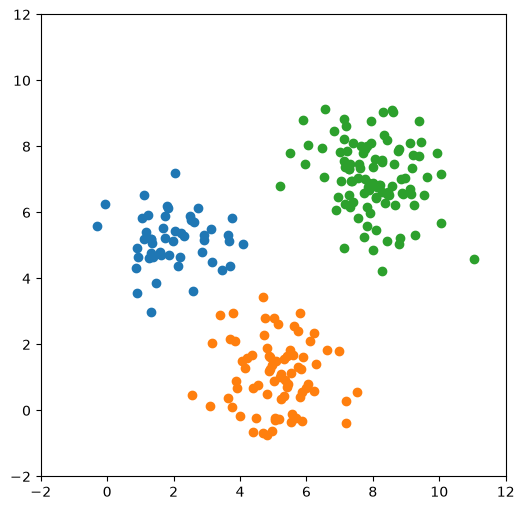

In [4]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập

In [5]:
dat1 = np.stack([x1,y1]).T
dat1.shape

(50, 2)

In [6]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

In [7]:
dat = np.vstack([dat1, dat2, dat3])
dat.shape

(225, 2)

### Sắp ngẫu nhiên các dòng

In [8]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

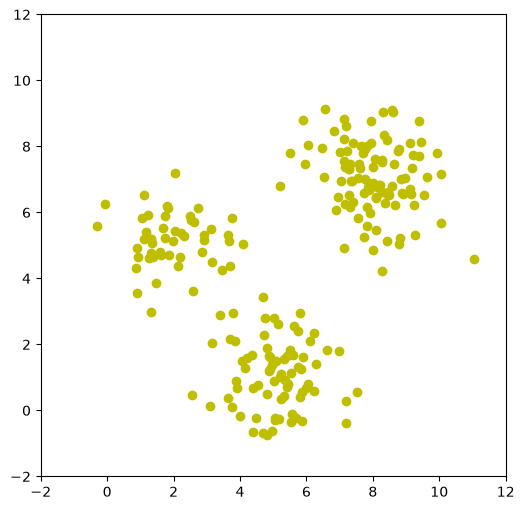

In [9]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm bằng DBSCAN

**=== Import lớp DBSCAN từ thư viện sklearn ===**

In [10]:
from sklearn.cluster import DBSCAN

### 2.1. Khởi tạo model và fit vào dữ liệu

In [15]:
# Giả sử chọn epsilon = 1, minPoints = 5
dbscan = DBSCAN(eps=1, min_samples=5)

**=== Thực hiện fit vào dữ liệu ===**

In [16]:
labels = dbscan.fit_predict(dat)

print("Các nhãn cụm:", np.unique(labels))

Các nhãn cụm: [-1  0  1  2]


### 2.2. Kiểm tra kết quả các cluster tìm được

**=== Lấy ra nhãn các clusters ===**

In [18]:
# Lấy ra nhãn các clusters
cluster_labels = np.unique(labels)

print("Các nhãn cluster:", cluster_labels)

Các nhãn cluster: [-1  0  1  2]


**=== Đếm xem mỗi cluster có bao nhiêu điểm ===**

In [19]:
unique, counts = np.unique(labels, return_counts=True)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} điểm")

Cluster -1: 7 điểm
Cluster 0: 98 điểm
Cluster 1: 73 điểm
Cluster 2: 47 điểm


**=== Hiển thị lên biểu đồ ===**

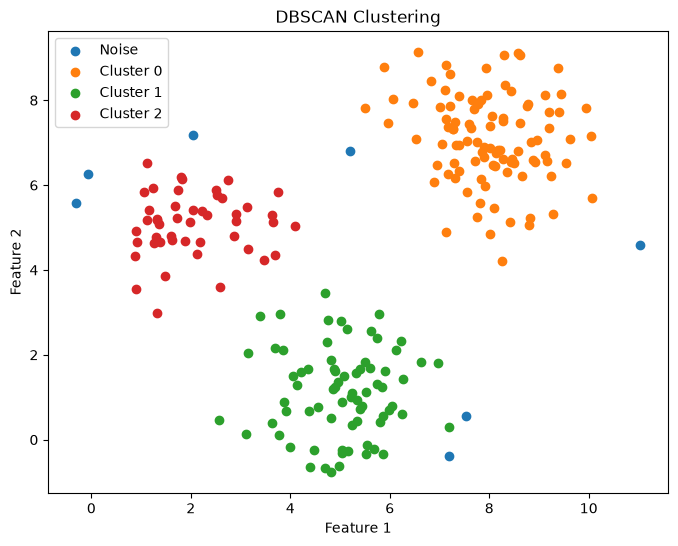

In [20]:
# === Hiển thị lên biểu đồ ===
plt.figure(figsize=(8, 6))

for cluster in np.unique(labels):
    points = dat[labels == cluster]
    
    if cluster == -1:
        plt.scatter(points[:, 0], points[:, 1], label="Noise")
    else:
        plt.scatter(points[:, 0], points[:, 1], label=f"Cluster {cluster}")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

### 2.3. Tính hiệu suất phân cụm

**=== Thử tính với hàm built-in của Sklearn ===**

In [22]:
from sklearn.metrics import silhouette_score

In [23]:
silhouette_score(dat, labels)

0.639460128792222

**=== Tính lại với các cụm không chứa điểm noise ===**

In [ ]:
import pandas as pd

### Bỏ đi các samples bị xác định là noise


In [27]:
mask = labels != -1

score = silhouette_score(dat[mask], labels[mask])
dat2 = dat[mask]
cluster2 = labels[mask]
print("Silhouette Score (không có noise):", score)

Silhouette Score (không có noise): 0.68542282500809


In [30]:
# Tạo một list rỗng để chứa hệ số Silhouette của mỗi sample
import pandas as pd
s_list = []

for i, sample in enumerate(dat2):
    label = cluster2[i]
    
    # Lấy ra các samples khác và nhãn khác
    other_samples = np.delete(dat2, i, axis=0)
    other_labels = np.delete(cluster2, i)
    
    # Tính khoảng cách từ sample đến tất cả các other_samples
    distances = np.linalg.norm(other_samples - sample, axis=1)
    
    # Tạo dataframe với 2 cột 'distance' và 'cluster'
    df_dist = pd.DataFrame({
        'distance': distances,
        'cluster': other_labels
    })
    
    # Lấy ra giá trị p, q tương ứng
    p = df_dist[df_dist['cluster'] == label]['distance'].mean()
    q = df_dist[df_dist['cluster'] != label].groupby('cluster')['distance'].mean().min()
    
    # Tính hệ số Silhouette cho sample
    s = (q - p) / max(p, q)
    s_list.append(s)

In [32]:
# Tính trung bình hệ số Silhouette của tất cả các samples
silhouette_score_manual = np.mean(s_list)
print("Silhouette Score:", silhouette_score_manual)

Silhouette Score: 0.6854228250080899


**==> Thử thực hiện lại mà không bỏ giá trị noise?**

In [33]:
# === Thử thực hiện lại mà không bỏ giá trị noise ===

s_list = []

for i, sample in enumerate(dat):
    label = labels[i]
    
    # Lấy các samples khác
    other_samples = np.delete(dat, i, axis=0)
    other_labels = np.delete(labels, i)
    
    # Tính khoảng cách
    distances = np.linalg.norm(other_samples - sample, axis=1)
    
    # Tạo dataframe
    df_dist = pd.DataFrame({
        'distance': distances,
        'cluster': other_labels
    })
    
    # Tính p
    p = df_dist[df_dist['cluster'] == label]['distance'].mean()
    
    # Tính q
    q = df_dist[df_dist['cluster'] != label].groupby('cluster')['distance'].mean().min()
    
    # Tính Silhouette
    s = (q - p) / max(p, q)
    s_list.append(s)

# Trung bình
silhouette_noise = np.mean(s_list)

print("Silhouette Score (có noise):", silhouette_noise)

Silhouette Score (có noise): 0.639460128792222
